In [3]:
import numpy as np
from matplotlib import pyplot as plt

import noctiluca as nl
import bayesmsd

In [2]:
data = nl.io.load.hdf5('/data/sgh/science/2024_minflux/20260106_chromatin_dynamics_all_data.h5', '/data')

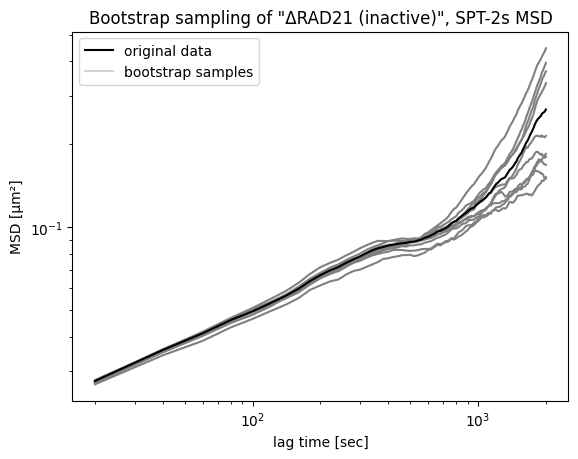

In [17]:
data.makeSelection(['array', 'ΔRAD21 (inactive)', 'SPT-2s'], logic=all)

dt = 20
T_max = 101

msd = nl.analysis.MSD(data)
plt.plot(dt*np.arange(1, T_max), msd[1:T_max],
         color='k', zorder=10, label='original data'
        )

for i in range(10):
    sample = np.random.randint(len(data), size=len(data))
    data_bs = nl.TaggedSet((data[i] for i in sample), hasTags=False)
    
    msd = nl.analysis.MSD(data_bs)
    plt.plot(dt*np.arange(1, T_max), msd[1:T_max],
             color='gray',
            )

plt.plot(0, 0, color='lightgray', label='bootstrap samples')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('lag time [sec]')
plt.ylabel('MSD [μm²]')
plt.title('Bootstrap sampling of "ΔRAD21 (inactive)", SPT-2s MSD')

plt.show()